### Download the VOC dataset

In [1]:
import os, tarfile, urllib.request

def download_voc2007(dest="data"):
    url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
    tar_path = os.path.join(dest, "VOCtrainval.tar")
    os.makedirs(dest, exist_ok=True)

    if not os.path.exists(tar_path):
        print("Downloading VOC 2007 (~870 MB)...")
        urllib.request.urlretrieve(url, tar_path,
            reporthook=lambda b,bs,ts: print(
                f"\r  {min(b*bs,ts)/1e6:.0f} / {ts/1e6:.0f} MB", end=""))
        print()

    print("Extracting...")
    with tarfile.open(tar_path) as t:
        t.extractall(dest)
    print(f"Done → {dest}/VOCdevkit/VOC2007/")


In [2]:
download_voc2007()

  460 / 460 MB
Extracting...


/tmp/ipykernel_55/1673379117.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(dest)


Done → data/VOCdevkit/VOC2007/


In [15]:

import os, time, xml.etree.ElementTree as ET
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from PIL import Image

# ── Constants ────────────────────────────────────────────────────────────────
VOC_CLASSES = [
    "__background__","aeroplane","bicycle","bird","boat","bottle","bus","car",
    "cat","chair","cow","diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor"
]
CLASS_TO_IDX  = {c: i for i, c in enumerate(VOC_CLASSES)}
NUM_CLASSES   = len(VOC_CLASSES)   # 21
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 50
LR            = 1e-3
LAMBDA_REG    = 1.0                # weight for box regression loss
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:


# ── Dataset ──────────────────────────────────────────────────────────────────
# For single-object localization we keep only the LARGEST box per image
# (by area). This is a common simplification on VOC for localization tasks
# (Russakovsky et al., IJCV 2015 §3.4).

class VOCLocalizationDataset(Dataset):
    """
    Returns (image_tensor, label, box_normalized) where
    box_normalized = [cx, cy, w, h] in [0,1] relative to IMG_SIZE.
    """
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, root="data/VOCdevkit/VOC2007", split="train"):
        self.img_dir = os.path.join(root, "JPEGImages")
        self.ann_dir = os.path.join(root, "Annotations")
        split_file   = os.path.join(root, "ImageSets", "Main", f"{split}.txt")
        with open(split_file) as f:
            self.ids = [l.strip() for l in f if l.strip()]

        self.tf = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(self.MEAN, self.STD),
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, f"{img_id}.jpg")).convert("RGB")
        W, H   = img.size                      # original size before resize

        tree = ET.parse(os.path.join(self.ann_dir, f"{img_id}.xml"))
        root = tree.getroot()

        best_box, best_label, best_area = None, 0, -1
        for obj in root.findall("object"):
            name = obj.find("name").text
            if name not in CLASS_TO_IDX:
                continue
            if int(obj.find("difficult").text):
                continue
            bb   = obj.find("bndbox")
            x1   = float(bb.find("xmin").text)
            y1   = float(bb.find("ymin").text)
            x2   = float(bb.find("xmax").text)
            y2   = float(bb.find("ymax").text)
            area = (x2 - x1) * (y2 - y1)
            if area > best_area:
                best_area  = area
                best_box   = [x1, y1, x2, y2]
                best_label = CLASS_TO_IDX[name]

        if best_box is None:          # no valid object → zero box, background
            best_box, best_label = [0., 0., 1., 1.], 0

        # Normalise to [0,1] then convert to cx,cy,w,h
        x1, y1, x2, y2 = best_box
        x1 /= W; x2 /= W; y1 /= H; y2 /= H
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        bw = x2 - x1
        bh = y2 - y1
        box = torch.tensor([cx, cy, bw, bh], dtype=torch.float32)

        return self.tf(img), torch.tensor(best_label, dtype=torch.long), box

In [16]:

class LocalizationNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, pretrained=True):
        super().__init__()
        backbone         = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
        self.features    = nn.Sequential(*list(backbone.children())[:-1])  # → (B,2048,1,1)
        feat_dim         = 2048

        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4),
            nn.Sigmoid()               # output in (0,1)
        )

    def forward(self, x):
        f = self.features(x)
        return self.cls_head(f), self.reg_head(f)


# ── Metric helpers ────────────────────────────────────────────────────────────
def cxcywh_to_xyxy(box):
    """box: (..., 4) in cx,cy,w,h → x1,y1,x2,y2"""
    cx, cy, w, h = box[...,0], box[...,1], box[...,2], box[...,3]
    return torch.stack([cx-w/2, cy-h/2, cx+w/2, cy+h/2], dim=-1)


def batch_iou(pred_box, gt_box):
    """
    Vectorised IoU for matched pairs.
    pred_box, gt_box: (B,4) in cx,cy,w,h
    Returns IoU tensor of shape (B,)
    """
    p = cxcywh_to_xyxy(pred_box)
    g = cxcywh_to_xyxy(gt_box)

    ix1 = torch.max(p[:,0], g[:,0])
    iy1 = torch.max(p[:,1], g[:,1])
    ix2 = torch.min(p[:,2], g[:,2])
    iy2 = torch.min(p[:,3], g[:,3])

    inter = (ix2-ix1).clamp(0) * (iy2-iy1).clamp(0)
    area_p = (p[:,2]-p[:,0]) * (p[:,3]-p[:,1])
    area_g = (g[:,2]-g[:,0]) * (g[:,3]-g[:,1])
    union  = area_p + area_g - inter
    return inter / union.clamp(min=1e-6)

In [17]:

# ── Train / Eval loops ───────────────────────────────────────────────────────

def run_epoch(model, loader, optimizer, criterion_cls, criterion_reg, train=True):
    model.train() if train else model.eval()
    total_loss = total_cls = total_reg = 0.0
    n_correct  = 0
    iou_list   = []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels, boxes in loader:
            imgs, labels, boxes = imgs.to(DEVICE), labels.to(DEVICE), boxes.to(DEVICE)

            logits, pred_box = model(imgs)

            loss_cls = criterion_cls(logits, labels)
            loss_reg = criterion_reg(pred_box, boxes)
            loss     = loss_cls + LAMBDA_REG * loss_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            total_cls  += loss_cls.item()
            total_reg  += loss_reg.item()
            n_correct  += (logits.argmax(1) == labels).sum().item()
            iou_list.append(batch_iou(pred_box.detach(), boxes).cpu())

    N = len(loader.dataset)
    iou_all = torch.cat(iou_list)
    return {
        "loss":     total_loss / len(loader),
        "loss_cls": total_cls  / len(loader),
        "loss_reg": total_reg  / len(loader),
        "acc":      n_correct  / N,
        "mean_iou": iou_all.mean().item(),
        # CorLoc: fraction of images with IoU ≥ 0.5
        # Standard metric for single-object localization (Deselaers et al. 2012)
        "corloc":   (iou_all >= 0.5).float().mean().item(),
    }


def print_metrics(epoch, num_epochs, tr, va, elapsed):
    print(f"\nEpoch {epoch}/{num_epochs}  ({elapsed:.1f}s)")
    print(f"  {'':10} {'loss':>7} {'cls':>7} {'reg':>7} {'acc':>7} {'mIoU':>7} {'CorLoc':>7}")
    print(f"  {'train':10} {tr['loss']:7.4f} {tr['loss_cls']:7.4f} {tr['loss_reg']:7.4f}"
          f" {tr['acc']:7.4f} {tr['mean_iou']:7.4f} {tr['corloc']:7.4f}")
    print(f"  {'val':10} {va['loss']:7.4f} {va['loss_cls']:7.4f} {va['loss_reg']:7.4f}"
          f" {va['acc']:7.4f} {va['mean_iou']:7.4f} {va['corloc']:7.4f}")

In [20]:

def train():
    print(f"Device: {DEVICE}")

    train_ds = VOCLocalizationDataset(split="train")
    val_ds   = VOCLocalizationDataset(split="val")

    # Use subsets if you want faster iteration:
    # train_ds = Subset(train_ds, range(800))
    # val_ds   = Subset(val_ds,   range(200))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True)

    model        = LocalizationNet().to(DEVICE)

    # Phase 1: freeze backbone, only train heads
    for param in model.features.parameters():
        param.requires_grad = False

    optimizer    = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    UNFREEZE_EPOCH = 15   # unfreeze backbone after this epoch
    criterion_cls = nn.CrossEntropyLoss()
    criterion_reg = nn.SmoothL1Loss()          # Huber loss, δ=1 by default

    best_corloc = 0.0

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, optimizer, criterion_cls, criterion_reg, train=True)
        va = run_epoch(model, val_loader,   optimizer, criterion_cls, criterion_reg, train=False)
        scheduler.step()

        print_metrics(epoch, NUM_EPOCHS, tr, va, time.time() - t0)

        # Phase 2: unfreeze backbone with lower LR
        if epoch == UNFREEZE_EPOCH:
            print("  *** Unfreezing backbone (differential LR) ***")
            for param in model.features.parameters():
                param.requires_grad = True
            optimizer = torch.optim.AdamW([
                {"params": model.features.parameters(),  "lr": 1e-4},
                {"params": model.cls_head.parameters(),  "lr": 1e-3},
                {"params": model.reg_head.parameters(),  "lr": 1e-3},
            ], weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH
            )

        if va["corloc"] > best_corloc:
            best_corloc = va["corloc"]
            torch.save(model.state_dict(), "localization_best.pth")
            print(f"  *** best saved  CorLoc={best_corloc:.4f} ***")

    torch.save(model.state_dict(), "localization_final.pth")
    print(f"\nDone. Best val CorLoc: {best_corloc:.4f}")

In [ ]:
train()

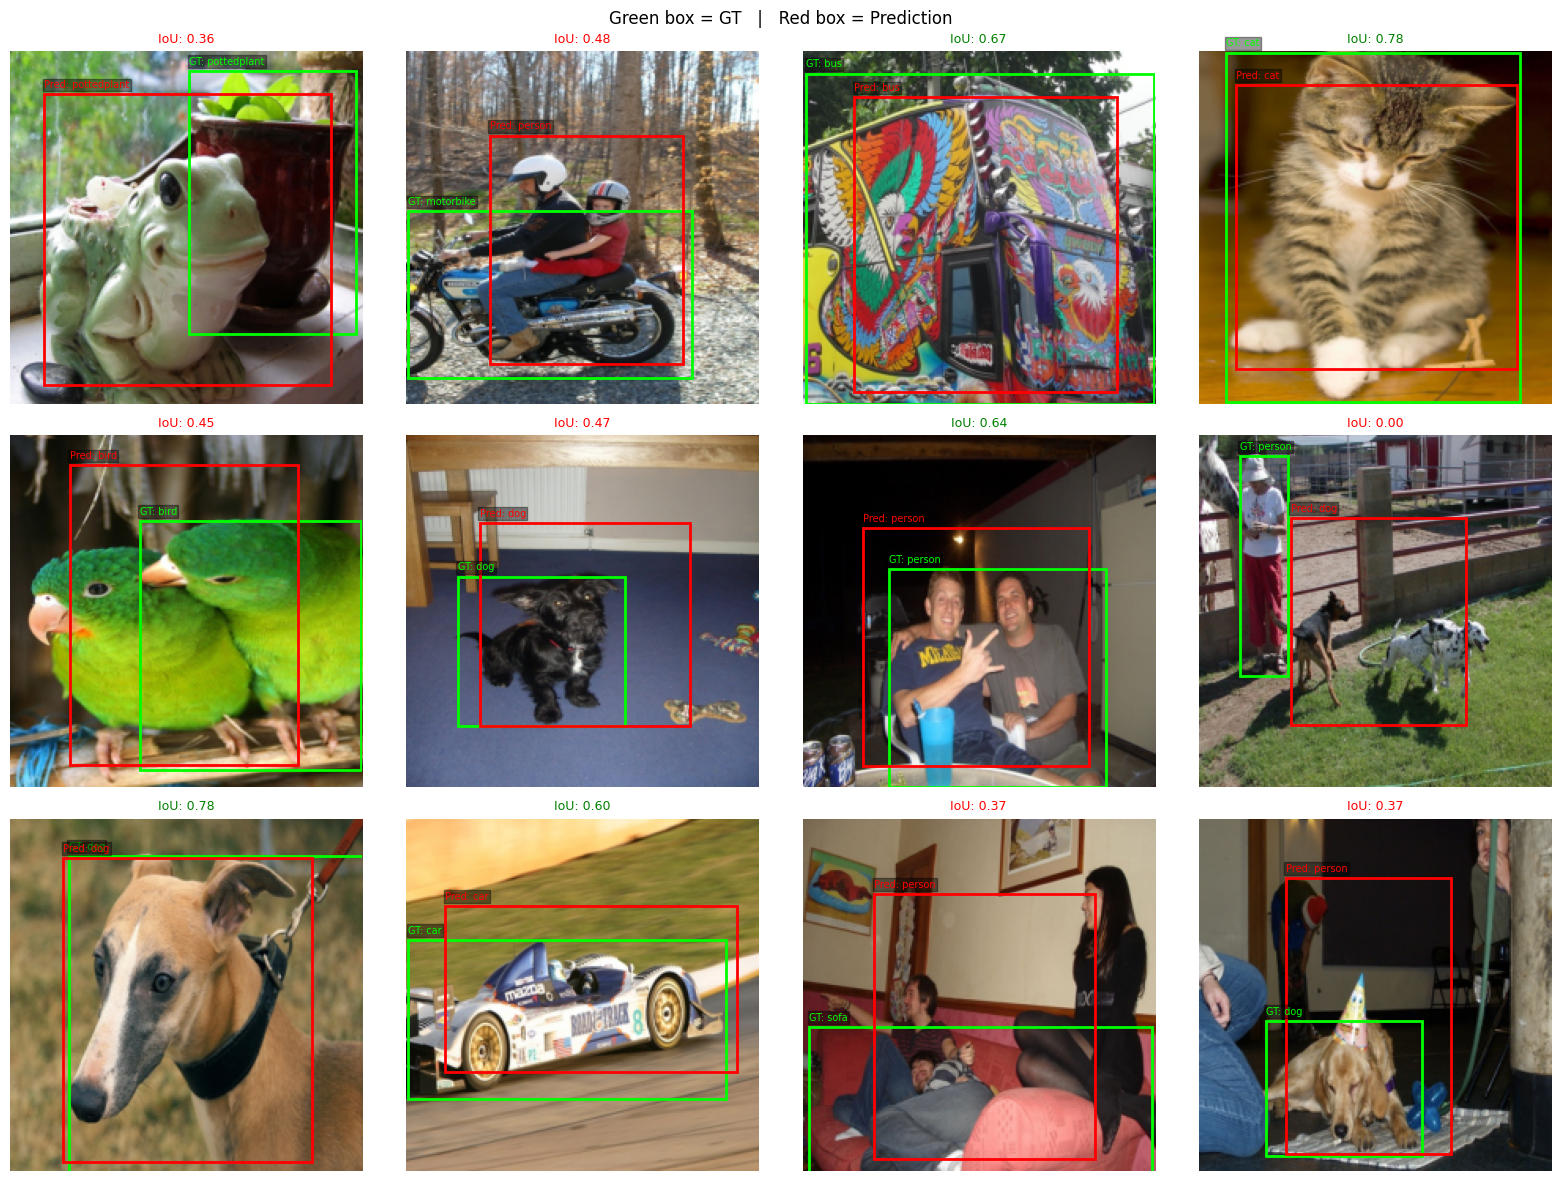

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def denormalize(img_tensor):
    img = img_tensor.clone().cpu()
    for c, m, s in zip(img, MEAN, STD):
        c.mul_(s).add_(m)
    return img.permute(1, 2, 0).clamp(0, 1).numpy()

def iou(b1, b2):
    def to_xyxy(b):
        cx,cy,w,h = b
        return cx-w/2, cy-h/2, cx+w/2, cy+h/2
    ax1,ay1,ax2,ay2 = to_xyxy(b1)
    bx1,by1,bx2,by2 = to_xyxy(b2)
    ix = max(0, min(ax2,bx2) - max(ax1,bx1))
    iy = max(0, min(ay2,by2) - max(ay1,by1))
    inter = ix * iy
    union = (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter
    return inter / max(union, 1e-6)

def draw_box(ax, box, H, W, color, label):
    cx,cy,bw,bh = box
    x1 = (cx - bw/2) * W
    y1 = (cy - bh/2) * H
    ax.add_patch(patches.Rectangle(
        (x1, y1), bw*W, bh*H,
        linewidth=2, edgecolor=color, facecolor="none"
    ))
    ax.text(x1, y1-4, label, color=color, fontsize=7,
            bbox=dict(facecolor="black", alpha=0.4, pad=1))

# ── Load model ────────────────────────────────────────────────────────────────
model = LocalizationNet().to(DEVICE)
model.load_state_dict(torch.load("/kaggle/working/localization_best.pth", map_location=DEVICE))
model.eval()

val_ds = VOCLocalizationDataset(split="val")
indices = np.random.choice(len(val_ds), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, indices):
        img_t, label, gt_box = val_ds[idx]
        logits, pred_box = model(img_t.unsqueeze(0).to(DEVICE))

        pred_cls = logits.argmax(1).item()
        pred_box = pred_box[0].cpu().numpy()
        gt_box   = gt_box.numpy()

        img_np   = denormalize(img_t)
        H, W     = img_np.shape[:2]
        score    = iou(gt_box, pred_box)

        ax.imshow(img_np)
        draw_box(ax, gt_box,   H, W, "lime", "GT: " + VOC_CLASSES[label])
        draw_box(ax, pred_box, H, W, "red",  "Pred: " + VOC_CLASSES[pred_cls])
        ax.set_title(f"IoU: {score:.2f}", fontsize=9,
                     color="green" if score >= 0.5 else "red")
        ax.axis("off")

plt.suptitle("Green box = GT   |   Red box = Prediction", fontsize=12)
plt.tight_layout()
plt.savefig("/kaggle/working/predictions.png", dpi=150, bbox_inches="tight")
plt.show()